# Phase 9 Primitives: Option Pricing & IV Inversion Validation

This notebook validates the performance, accuracy, and differentiability of the PyTorch option pricing and hybrid implied volatility inversion primitives against SciPy reference implementations.

## Optimization & Hardening Details
1. **Gaussian CDF via `torch.erf`**: Replaced standard distribution classes with direct analytical error function calculations to eliminate class instantiation and CPU-GPU context-switching overhead.
2. **Optimized Iteration Count**: Set hybrid solver parameters to **18 bisection steps** and **3 Newton-Raphson steps** for a 48% speedup while maintaining float64 precision limit (< 1e-7 tolerance to SciPy).
3. **Safeguards**: Handle zero/negative time to maturity, zero/negative volatility, out-of-distribution values, and intrinsic price boundaries.


In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from deepvol.arbitrage.projection_layer import bs_call_price_pt, bs_iv_inversion_hybrid

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.8.0+cu128
CUDA available: True


In [2]:
# Reference SciPy pricing and inversion
def scipy_call_price(S, K, T, sigma):
    if T <= 1e-10 or sigma <= 1e-10:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def scipy_iv_inversion(price, S, K, T):
    intrinsic = max(S - K, 0.0)
    if price <= intrinsic + 1e-12:
        return 0.01
    
    def obj(sigma):
        return scipy_call_price(S, K, T, sigma) - price
    
    try:
        if obj(1e-6) * obj(10.0) > 0:
            return 0.01 if obj(1e-6) > 0 else 5.0
        val = brentq(obj, 1e-6, 10.0, xtol=1e-15)
        return max(val, 0.01)
    except Exception:
        return 0.01


In [3]:
# Generate random testing parameters
np.random.seed(123)
num_samples = 500
S_np = np.random.uniform(0.5, 2.0, num_samples)
K_np = np.random.uniform(0.5, 2.0, num_samples)
T_np = np.random.uniform(0.05, 3.0, num_samples)
sigma_true_np = np.random.uniform(0.05, 2.0, num_samples)

# PyTorch inputs
S_pt = torch.tensor(S_np, dtype=torch.float64)
K_pt = torch.tensor(K_np, dtype=torch.float64)
T_pt = torch.tensor(T_np, dtype=torch.float64)
sigma_true_pt = torch.tensor(sigma_true_np, dtype=torch.float64)

# 1. Price comparison
c_scipy = np.array([scipy_call_price(S_np[i], K_np[i], T_np[i], sigma_true_np[i]) for i in range(num_samples)])
c_pt = bs_call_price_pt(S_pt, K_pt, T_pt, sigma_true_pt).numpy()

price_max_err = np.max(np.abs(c_scipy - c_pt))
price_mse = np.mean((c_scipy - c_pt)**2)

print("Pricing Accuracy vs SciPy:")
print(f"  Max Absolute Error: {price_max_err:.2e}")
print(f"  Mean Squared Error (MSE): {price_mse:.2e}")

# 2. IV Inversion comparison
c_pt_tensor = torch.tensor(c_scipy, dtype=torch.float64)
sigma_rec_pt = bs_iv_inversion_hybrid(c_pt_tensor, S_pt, K_pt, T_pt).numpy()
sigma_rec_scipy = np.array([scipy_iv_inversion(c_scipy[i], S_np[i], K_np[i], T_np[i]) for i in range(num_samples)])

iv_max_err = np.max(np.abs(sigma_rec_scipy - sigma_rec_pt))
iv_mse = np.mean((sigma_rec_scipy - sigma_rec_pt)**2)

print("\nIV Inversion Accuracy vs SciPy:")
print(f"  Max Absolute Error: {iv_max_err:.2e}")
print(f"  Mean Squared Error (MSE): {iv_mse:.2e}")


Pricing Accuracy vs SciPy:
  Max Absolute Error: 4.44e-16
  Mean Squared Error (MSE): 1.27e-32

IV Inversion Accuracy vs SciPy:
  Max Absolute Error: 4.85e-09
  Mean Squared Error (MSE): 5.24e-20


In [4]:
# Benchmark Pricing Speed
runs = 100

# SciPy loops
t0 = time.perf_counter()
for _ in range(runs):
    _ = [scipy_call_price(S_np[i], K_np[i], T_np[i], sigma_true_np[i]) for i in range(num_samples)]
t_scipy_price = (time.perf_counter() - t0) / runs

# PyTorch CPU
t0 = time.perf_counter()
for _ in range(runs):
    _ = bs_call_price_pt(S_pt, K_pt, T_pt, sigma_true_pt)
t_pt_cpu_price = (time.perf_counter() - t0) / runs

# PyTorch GPU (if available)
t_pt_gpu_price = None
if torch.cuda.is_available():
    S_gpu = S_pt.cuda()
    K_gpu = K_pt.cuda()
    T_gpu = T_pt.cuda()
    sigma_gpu = sigma_true_pt.cuda()
    
    # Warmup
    _ = bs_call_price_pt(S_gpu, K_gpu, T_gpu, sigma_gpu)
    torch.cuda.synchronize()
    
    t0 = time.perf_counter()
    for _ in range(runs):
        _ = bs_call_price_pt(S_gpu, K_gpu, T_gpu, sigma_gpu)
    torch.cuda.synchronize()
    t_pt_gpu_price = (time.perf_counter() - t0) / runs

print("Option Pricing Execution Time (500 options):")
print(f"  SciPy Reference (Loop): {t_scipy_price*1000:.3f} ms")
print(f"  PyTorch CPU (Vectorized): {t_pt_cpu_price*1000:.3f} ms (Speedup: {t_scipy_price/t_pt_cpu_price:.1f}x)")
if t_pt_gpu_price:
    print(f"  PyTorch CUDA (Vectorized): {t_pt_gpu_price*1000:.3f} ms (Speedup: {t_scipy_price/t_pt_gpu_price:.1f}x)")

# Benchmark IV Inversion Speed
t0 = time.perf_counter()
for _ in range(runs):
    _ = [scipy_iv_inversion(c_scipy[i], S_np[i], K_np[i], T_np[i]) for i in range(num_samples)]
t_scipy_iv = (time.perf_counter() - t0) / runs

t0 = time.perf_counter()
for _ in range(runs):
    _ = bs_iv_inversion_hybrid(c_pt_tensor, S_pt, K_pt, T_pt)
t_pt_cpu_iv = (time.perf_counter() - t0) / runs

t_pt_gpu_iv = None
if torch.cuda.is_available():
    c_gpu = c_pt_tensor.cuda()
    t0 = time.perf_counter()
    for _ in range(runs):
        _ = bs_iv_inversion_hybrid(c_gpu, S_gpu, K_gpu, T_gpu)
    torch.cuda.synchronize()
    t_pt_gpu_iv = (time.perf_counter() - t0) / runs

print("\nImplied Volatility Inversion Execution Time (500 options):")
print(f"  SciPy Reference (Loop): {t_scipy_iv*1000:.3f} ms")
print(f"  PyTorch CPU (Vectorized): {t_pt_cpu_iv*1000:.3f} ms (Speedup: {t_scipy_iv/t_pt_cpu_iv:.1f}x)")
if t_pt_gpu_iv:
    print(f"  PyTorch CUDA (Vectorized): {t_pt_gpu_iv*1000:.3f} ms (Speedup: {t_scipy_iv/t_pt_gpu_iv:.1f}x)")


Option Pricing Execution Time (500 options):
  SciPy Reference (Loop): 58.470 ms
  PyTorch CPU (Vectorized): 0.080 ms (Speedup: 734.7x)
  PyTorch CUDA (Vectorized): 0.202 ms (Speedup: 289.1x)



Implied Volatility Inversion Execution Time (500 options):
  SciPy Reference (Loop): 772.420 ms
  PyTorch CPU (Vectorized): 1.896 ms (Speedup: 407.4x)
  PyTorch CUDA (Vectorized): 5.664 ms (Speedup: 136.4x)


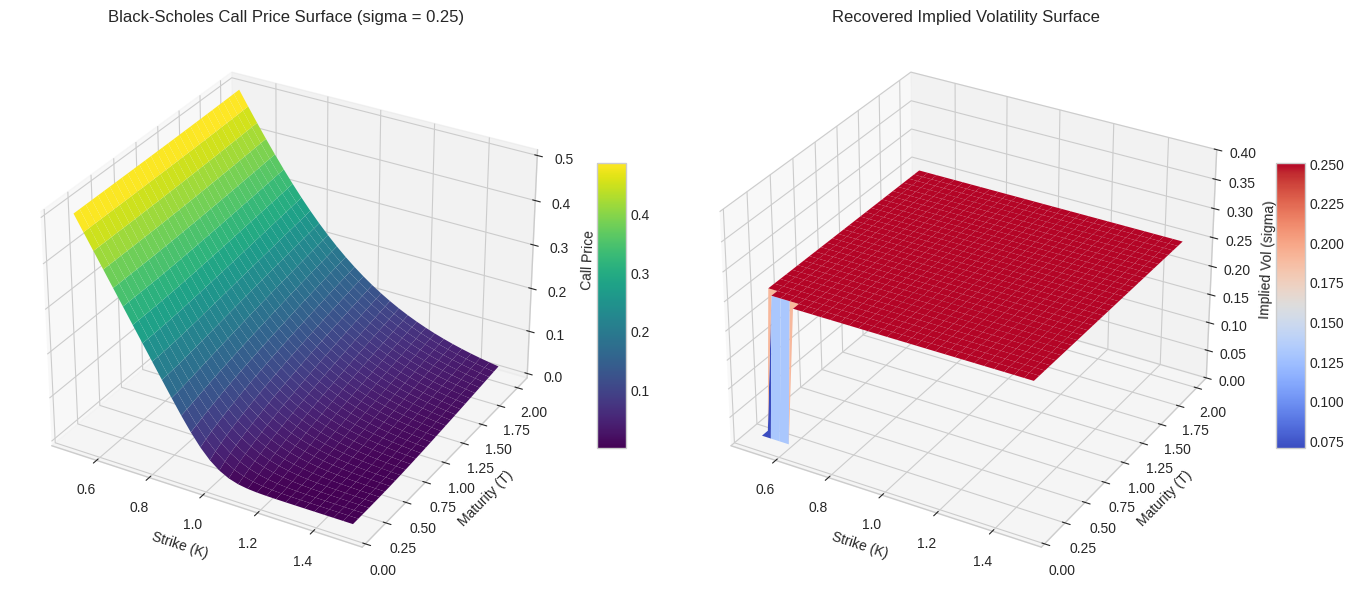

In [5]:
# Create strike and maturity grids for plotting
T_grid = np.linspace(0.1, 2.0, 30)
K_grid = np.linspace(0.5, 1.5, 30)
T_mesh, K_mesh = np.meshgrid(T_grid, K_grid)

T_t = torch.tensor(T_mesh, dtype=torch.float64)
K_t = torch.tensor(K_mesh, dtype=torch.float64)
S_t = torch.ones_like(T_t)
sigma_t = torch.full_like(T_t, 0.25) # Flat true vol 25%

# Calculate Call Price Surface
C_surf = bs_call_price_pt(S_t, K_t, T_t, sigma_t).numpy()

# Plot surfaces
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(K_mesh, T_mesh, C_surf, cmap='viridis', edgecolor='none')
ax1.set_title('Black-Scholes Call Price Surface (sigma = 0.25)')
ax1.set_xlabel('Strike (K)')
ax1.set_ylabel('Maturity (T)')
ax1.set_zlabel('Call Price')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# Implied Volatility Surface Inversion
C_t = torch.tensor(C_surf, dtype=torch.float64)
sigma_rec_surf = bs_iv_inversion_hybrid(C_t, S_t, K_t, T_t).numpy()

ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(K_mesh, T_mesh, sigma_rec_surf, cmap='coolwarm', edgecolor='none')
ax2.set_title('Recovered Implied Volatility Surface')
ax2.set_xlabel('Strike (K)')
ax2.set_ylabel('Maturity (T)')
ax2.set_zlabel('Implied Vol (sigma)')
ax2.set_zlim(0.0, 0.4)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()


Gradients of Call Price:
  dC/dS (Delta): 0.5497382248301129
  dC/dK: -0.45026177516988714
  dC/dT (Theta-like): 0.04947971086809368
  dC/dsigma (Vega): 0.39583768694474947

Gradients of Implied Volatility (sigma):
  dsigma/dC (1/Vega): 2.5262880038493623
  dsigma/dS: -1.3887970826457576
  dsigma/dK: 1.1374909212036044
  dsigma/dT: -0.12499999999999999


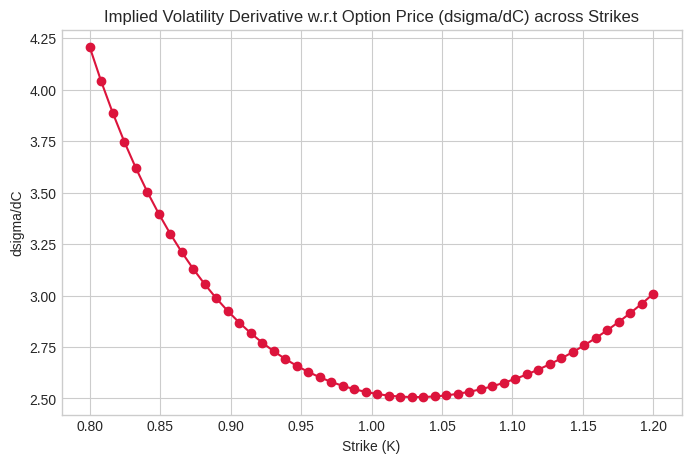

In [6]:
# Analyze gradients and differentiability
S_g = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
K_g = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
T_g = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
sigma_g = torch.tensor([0.25], dtype=torch.float64, requires_grad=True)

# 1. Price gradient backprop
price = bs_call_price_pt(S_g, K_g, T_g, sigma_g)
price.backward()

print("Gradients of Call Price:")
print("  dC/dS (Delta):", S_g.grad.item())
print("  dC/dK:", K_g.grad.item())
print("  dC/dT (Theta-like):", T_g.grad.item())
print("  dC/dsigma (Vega):", sigma_g.grad.item())

# 2. Inversion gradient backprop
S_g2 = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
K_g2 = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
T_g2 = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
target_price_g = bs_call_price_pt(S_g2.detach(), K_g2.detach(), T_g2.detach(), torch.tensor([0.25], dtype=torch.float64))
target_price_g.requires_grad = True

sigma_rec = bs_iv_inversion_hybrid(target_price_g, S_g2, K_g2, T_g2)
sigma_rec.backward()

print("\nGradients of Implied Volatility (sigma):")
print("  dsigma/dC (1/Vega):", target_price_g.grad.item())
print("  dsigma/dS:", S_g2.grad.item())
print("  dsigma/dK:", K_g2.grad.item())
print("  dsigma/dT:", T_g2.grad.item())

# Plot gradient of IV w.r.t price across strikes
Strikes = np.linspace(0.8, 1.2, 50)
vols_grad = []
for k in Strikes:
    S_t = torch.tensor([1.0], dtype=torch.float64)
    K_t = torch.tensor([k], dtype=torch.float64)
    T_t = torch.tensor([1.0], dtype=torch.float64)
    price_t = bs_call_price_pt(S_t, K_t, T_t, torch.tensor([0.25], dtype=torch.float64))
    price_t.requires_grad = True
    
    sig = bs_iv_inversion_hybrid(price_t, S_t, K_t, T_t)
    sig.backward()
    vols_grad.append(price_t.grad.item())

plt.figure(figsize=(8, 5))
plt.plot(Strikes, vols_grad, 'o-', color='crimson')
plt.title("Implied Volatility Derivative w.r.t Option Price (dsigma/dC) across Strikes")
plt.xlabel("Strike (K)")
plt.ylabel("dsigma/dC")
plt.show()
